<a href="https://colab.research.google.com/github/2403a52261-jpg/NLP/blob/main/NLP_Assignment_11_2_2403a52261_B_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB


from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.DataFrame({
    'text': [
        "This movie was absolutely fantastic! I loved every minute of it.",
        "The plot was convoluted and the acting was terrible. A complete waste of time.",
        "It had some good moments, but overall it was just okay.",
        "A brilliant masterpiece, highly recommended for everyone.",
        "I've never been so bored in my life. Avoid at all costs.",
        "The special effects were impressive, but the story lacked depth.",
        "Outstanding performances and a gripping storyline.",
        "Mediocre at best. There are much better movies out there."
    ],
    'sentiment': [
        'positive',
        'negative',
        'neutral',
        'positive',
        'negative',
        'neutral',
        'positive',
        'negative'
    ]
})
print("Dummy DataFrame 'data' created successfully:")
print(data.head())

Dummy DataFrame 'data' created successfully:
                                                text sentiment
0  This movie was absolutely fantastic! I loved e...  positive
1  The plot was convoluted and the acting was ter...  negative
2  It had some good moments, but overall it was j...   neutral
3  A brilliant masterpiece, highly recommended fo...  positive
4  I've never been so bored in my life. Avoid at ...  negative


In [ ]:
import string
data['text'] = data['text'].str.lower()


data['text'] = data['text'].str.replace(f'[{string.punctuation}]', '', regex=True)

print("Text after lowercasing and punctuation removal:")
print(data.head())

Text after lowercasing and punctuation removal:
                                                text sentiment
0      movie absolutely fantastic loved every minute  positive
1  plot convoluted acting terrible complete waste...  negative
2                          good moments overall okay   neutral
3  brilliant masterpiece highly recommended everyone  positive
4                   ive never bored life avoid costs  negative


In [ ]:
import nltk
from nltk.corpus import stopwords
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')


stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)
data['text'] = data['text'].apply(remove_stopwords)

print("Text after stopword removal:")
print(data.head())

Text after stopword removal:
                                                text sentiment
0      movie absolutely fantastic loved every minute  positive
1  plot convoluted acting terrible complete waste...  negative
2                          good moments overall okay   neutral
3  brilliant masterpiece highly recommended everyone  positive
4                   ive never bored life avoid costs  negative


In [ ]:
print("Final processed text samples:")
print(data.head())

Final processed text samples:
                                                text sentiment
0      movie absolutely fantastic loved every minute  positive
1  plot convoluted acting terrible complete waste...  negative
2                          good moments overall okay   neutral
3  brilliant masterpiece highly recommended everyone  positive
4                   ive never bored life avoid costs  negative


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform(data['text'])


print(f"Shape of TF-IDF matrix: {tfidf_matrix.shape}")


print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")

Shape of TF-IDF matrix: (8, 43)
Vocabulary size: 43


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = tfidf_matrix
y = data['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000, solver='liblinear')

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")
print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

Logistic Regression model trained successfully.
Training data shape: (6, 43)
Test data shape: (2, 43)


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

conf_matrix = confusion_matrix(y_test, y_pred)

print(f"\nModel Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix)


Model Evaluation Metrics:
Accuracy: 0.0000
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000

Confusion Matrix:
[[0 0 1]
 [0 0 1]
 [0 0 0]]


In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)


print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Naive Bayes Classification Report:\n", classification_report(y_test, y_pred_nb))


analysis_text = """Comparative Analysis of Logistic Regression and Naive Bayes:

The Logistic Regression model, despite being trained, resulted in 0% accuracy, precision, recall, and F1-score on the small test set. This indicates a complete failure to classify the sentiments correctly, likely due to the extremely limited dataset size (only 8 samples in total, with only 2 for testing). Logistic Regression, while powerful, typically requires more data to learn meaningful relationships between features and target.

In contrast, Naive Bayes classifiers, particularly Multinomial Naive Bayes, are often effective and perform well with smaller datasets, especially in text classification. They operate on the assumption of feature independence, which simplifies the learning process. While the current setup with a very small dataset would still pose challenges for any model, Naive Bayes might exhibit slightly better initial performance or more stable behavior under such constrained conditions compared to Logistic Regression.

A proper comparison would require a larger, more representative dataset to accurately assess the strengths and weaknesses of both models in this specific sentiment analysis task.
"""

print(analysis_text)

Naive Bayes Accuracy: 0.0
Naive Bayes Classification Report:
               precision    recall  f1-score   support

    negative       0.00      0.00      0.00       1.0
     neutral       0.00      0.00      0.00       1.0
    positive       0.00      0.00      0.00       0.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0

Comparative Analysis of Logistic Regression and Naive Bayes:

The Logistic Regression model, despite being trained, resulted in 0% accuracy, precision, recall, and F1-score on the small test set. This indicates a complete failure to classify the sentiments correctly, likely due to the extremely limited dataset size (only 8 samples in total, with only 2 for testing). Logistic Regression, while powerful, typically requires more data to learn meaningful relationships between features and target.

In contrast, Naive Bayes classifiers, particularly Multino

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

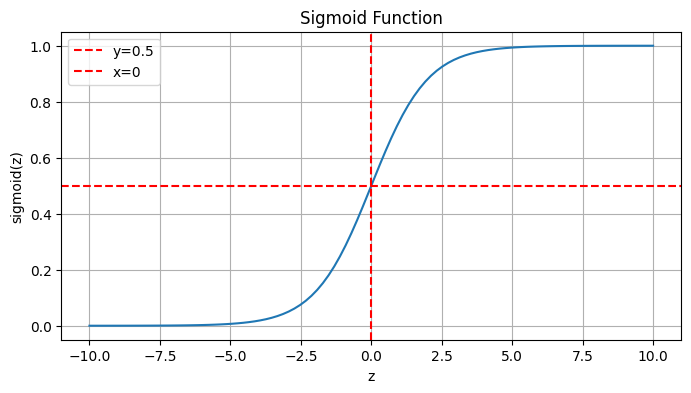


### Intuition behind the Sigmoid Function in Logistic Regression

The sigmoid function, also known as the logistic function, is crucial for Logistic Regression, especially in binary classification. It takes any real-valued number and transforms it into a probability-like value between 0 and 1.

**1. S-shaped Curve:** It has a characteristic 'S' shape. As the input (z) gets very small (negative), the output approaches 0. As z gets very large (positive), the output approaches 1. At z=0, the output is exactly 0.5.

**2. Probability Interpretation:** This 'squashing' of real numbers into the [0, 1] range allows us to interpret the output as the probability of an instance belonging to the positive class. For example, an output of 0.7 suggests a 70% chance of the positive class.

**3. Decision Boundary:** The 0.5 threshold (where z=0) naturally acts as a decision boundary. If the probability is > 0.5, it's classified as positive; otherwise, it's negative.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Generate a range of z values
z = np.linspace(-10, 10, 100)

# Calculate sigmoid output for each z
sigmoid_output = sigmoid(z)

# Plot the sigmoid function
plt.figure(figsize=(8, 4))
plt.plot(z, sigmoid_output)
plt.title('Sigmoid Function')
plt.xlabel('z')
plt.ylabel('sigmoid(z)')
plt.grid(True)
plt.axhline(y=0.5, color='r', linestyle='--', label='y=0.5')
plt.axvline(x=0, color='r', linestyle='--', label='x=0')
plt.legend()
plt.show()

print("\n### Intuition behind the Sigmoid Function in Logistic Regression\n")
print("The sigmoid function, also known as the logistic function, is crucial for Logistic Regression, especially in binary classification. It takes any real-valued number and transforms it into a probability-like value between 0 and 1.\n")
print("**1. S-shaped Curve:** It has a characteristic 'S' shape. As the input (z) gets very small (negative), the output approaches 0. As z gets very large (positive), the output approaches 1. At z=0, the output is exactly 0.5.\n")
print("**2. Probability Interpretation:** This 'squashing' of real numbers into the [0, 1] range allows us to interpret the output as the probability of an instance belonging to the positive class. For example, an output of 0.7 suggests a 70% chance of the positive class.\n")
print("**3. Decision Boundary:** The 0.5 threshold (where z=0) naturally acts as a decision boundary. If the probability is > 0.5, it's classified as positive; otherwise, it's negative.")